# Fase 2: Visualizzazione ed Analisi Esplorativa dei Dati (EDA)

In questo notebook si analizzano le statistiche descrittive delle variabili cliniche continue, con confronto tra sani e malati, calcolo delle correlazioni lineari e utilizzo di grafici bidimensionali (pairplot) e tridimensionali (3D scatter plot) per l'ispezione visiva delle distribuzioni dei dati originali rispetto a quelli imputati con il KNN.

In [1]:
# Importazione delle librerie per la manipolazione dati e la visualizzazione grafica
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Impostiamo uno stile grafico elegante per Seaborn
sns.set_theme(style="whitegrid")

In [2]:
# Caricamento del dataset originale (non pulito) e quello pulito ed imputato
dati_originali = pd.read_csv("../Dataset/Original/framingham_heart_study.csv")  
dati_puliti = pd.read_csv("../Dataset/Clean/framingham_clean.csv")

# Variabili continue di interesse clinico su cui focalizzare l'analisi
variabili_continue = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

In [3]:
# Controlliamo la presenza di righe duplicate nel dataset pulito
numero_duplicati = dati_puliti.duplicated().sum()
print(f"Numero di righe duplicate nel dataset pulito: {numero_duplicati}")

Numero di righe duplicate nel dataset pulito: 0


In [4]:
# Visualizzazione delle statistiche descrittive per le variabili continue del dataset originale
dati_originali[variabili_continue].describe()

In [5]:
# Visualizzazione delle statistiche descrittive per le variabili continue del dataset pulito ed imputato
dati_puliti[variabili_continue].describe()

In [6]:
# Analisi delle medie e deviazioni standard delle variabili cliniche stratificate per la presenza o assenza di rischio CHD a 10 anni
tabella_sintesi = dati_puliti.groupby('TenYearCHD')[variabili_continue].agg(['mean', 'std']).T
print("Confronto Medie e Deviazioni Standard tra Sani (0) e Malati (1):")
print(tabella_sintesi)

Confronto Medie e Deviazioni Standard tra Sani (0) e Malati (1):
TenYearCHD            False       True 
age        mean   48.756817   54.145963
           std     8.410718    8.005663
cigsPerDay mean    8.651642   10.596273
           std    11.677404   12.999882
totChol    mean  235.164775  245.338820
           std    43.589248   47.814519
sysBP      mean  130.340289  143.618789
           std    20.455326   26.690282
diaBP      mean   82.168614   86.981366
           std    11.337924   14.026900
BMI        mean   25.668807   26.520550
           std     3.978366    4.494626
heartRate  mean   75.758486   76.533230
           std    11.990120   12.210673
glucose    mean   80.710518   88.498447
           std    18.266274   39.661724


<string>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


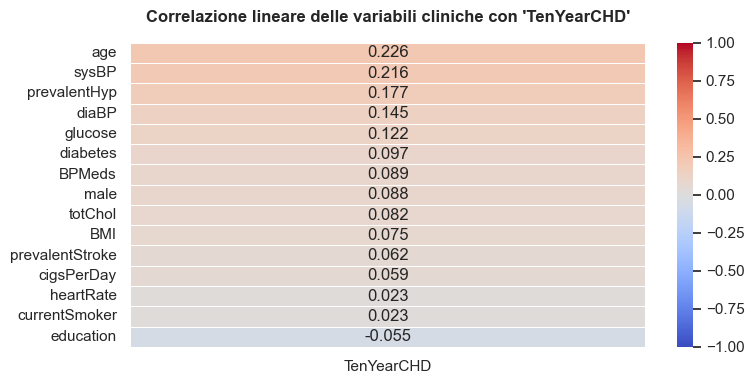

In [7]:
# Calcolo della correlazione lineare di Pearson tra le variabili
matrice_correlazione = dati_puliti.corr()

# Ordiniamo i coefficienti di correlazione rispetto a 'TenYearCHD' (escludendo la variabile stessa)
correlazione_ordinata_target = matrice_correlazione[["TenYearCHD"]].sort_values(by="TenYearCHD", ascending=False)
correlazione_ordinata_target = correlazione_ordinata_target.drop("TenYearCHD")

# Visualizzazione delle correlazioni tramite una heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(
    correlazione_ordinata_target, 
    annot=True,          
    fmt=".3f",           
    cmap="coolwarm",     
    vmin=-1, vmax=1,     
    linewidths=0.5
)

plt.title("Correlazione lineare delle variabili cliniche con 'TenYearCHD'", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [8]:
# Ricerca delle correlazioni più forti (in valore assoluto) tra tutte le coppie di variabili nel dataset
triangolo_superiore = matrice_correlazione.where(np.triu(np.ones(matrice_correlazione.shape), k=1).astype(bool))
serie_correlazioni = triangolo_superiore.unstack().dropna()
correlazioni_assolute_ordinate = serie_correlazioni.abs().sort_values(ascending=False)

print("📌 LE 5 CORRELAZIONI PIÙ RILEVANTI NEL DATASET:")
print("-" * 50)
for (varA, varB) in correlazioni_assolute_ordinate.head(5).index:
    coefficiente = serie_correlazioni[(varA, varB)]
    print(f"🔗 {varB} <--> {varA}  |  Coefficiente di Correlazione: {coefficiente:.4f}")

📌 LE 5 CORRELAZIONI PIÙ RILEVANTI NEL DATASET:
--------------------------------------------------
🔗 sysBP <--> diaBP  |  Coefficiente di Correlazione: 0.7840
🔗 currentSmoker <--> cigsPerDay  |  Coefficiente di Correlazione: 0.7709
🔗 prevalentHyp <--> sysBP  |  Coefficiente di Correlazione: 0.6967
🔗 prevalentHyp <--> diaBP  |  Coefficiente di Correlazione: 0.6159
🔗 diabetes <--> glucose  |  Coefficiente di Correlazione: 0.6004


<string>:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


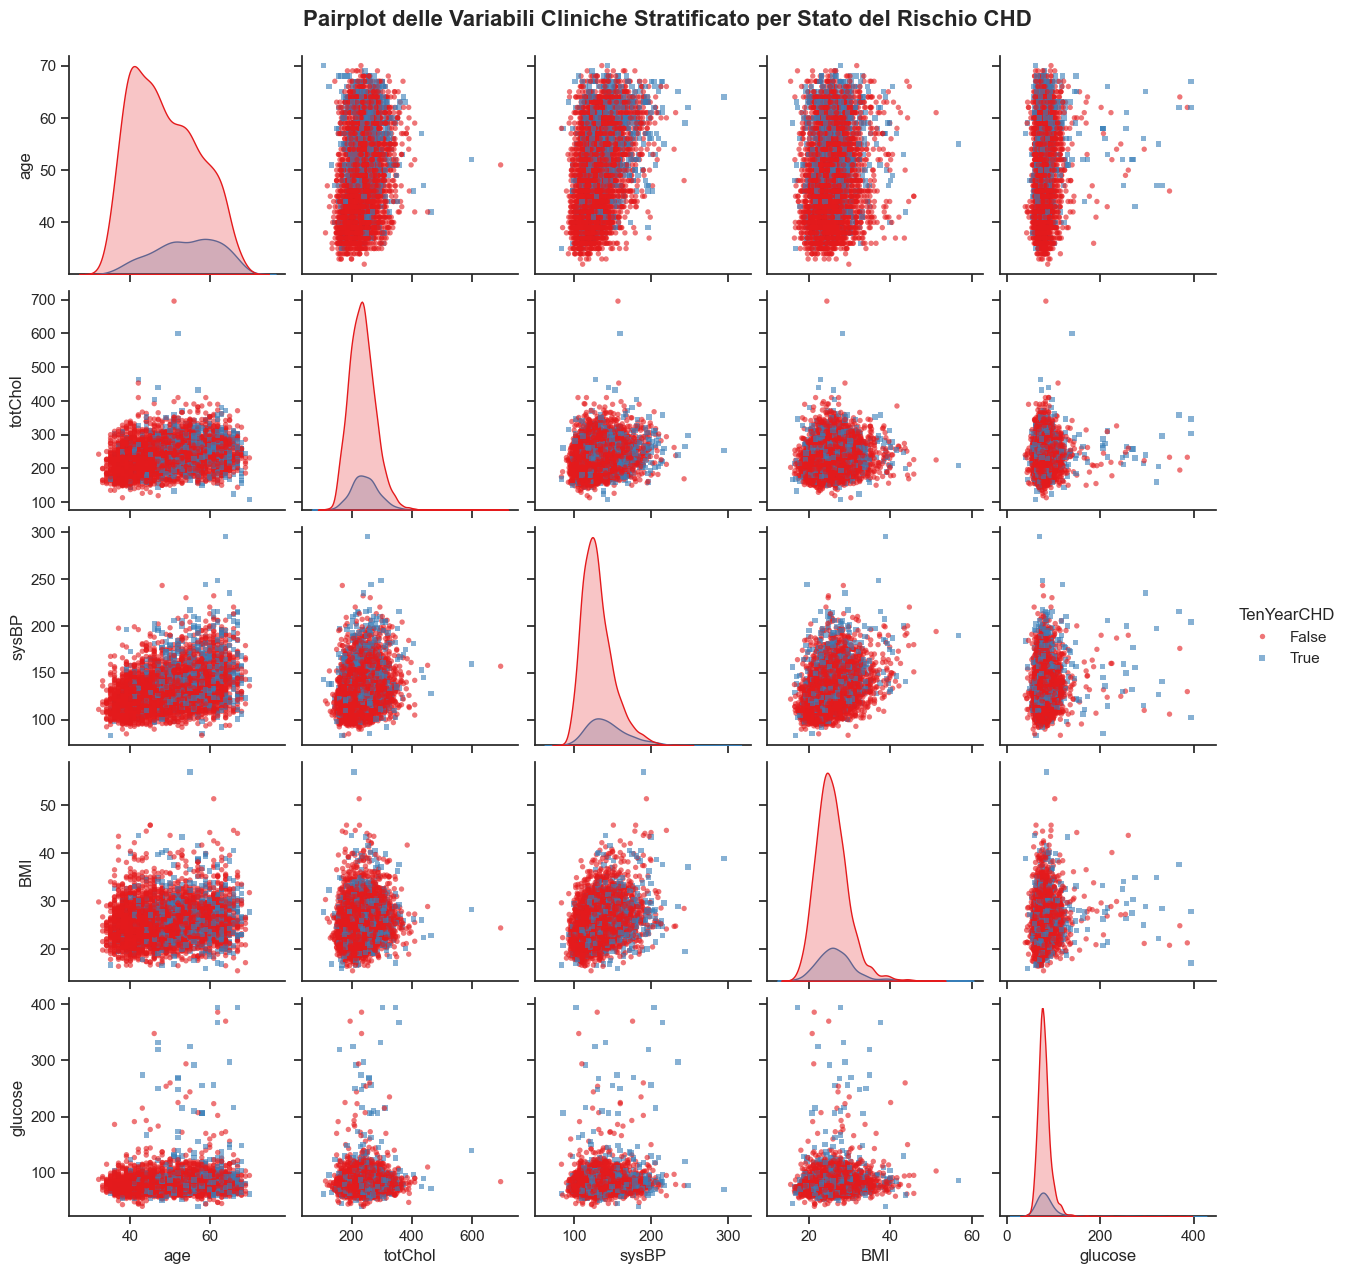

In [9]:
# Generazione di un pairplot per esaminare visivamente le relazioni bivariate tra le variabili chiave
sns.set_theme(style="ticks")

variabili_selezione = ['age', 'totChol', 'sysBP', 'BMI', 'glucose', 'TenYearCHD']

grid = sns.pairplot(
    data=dati_puliti[variabili_selezione], 
    hue='TenYearCHD', 
    palette='Set1',          
    diag_kind='kde', 
    markers=['o', 's'],      
    plot_kws={'alpha': 0.6, 's': 15, 'edgecolor': 'none'} 
)

plt.suptitle("Pairplot delle Variabili Cliniche Stratificato per Stato del Rischio CHD", 
             y=1.02, fontsize=16, fontweight='bold')
plt.show()

<string>:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
<string>:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
<string>:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


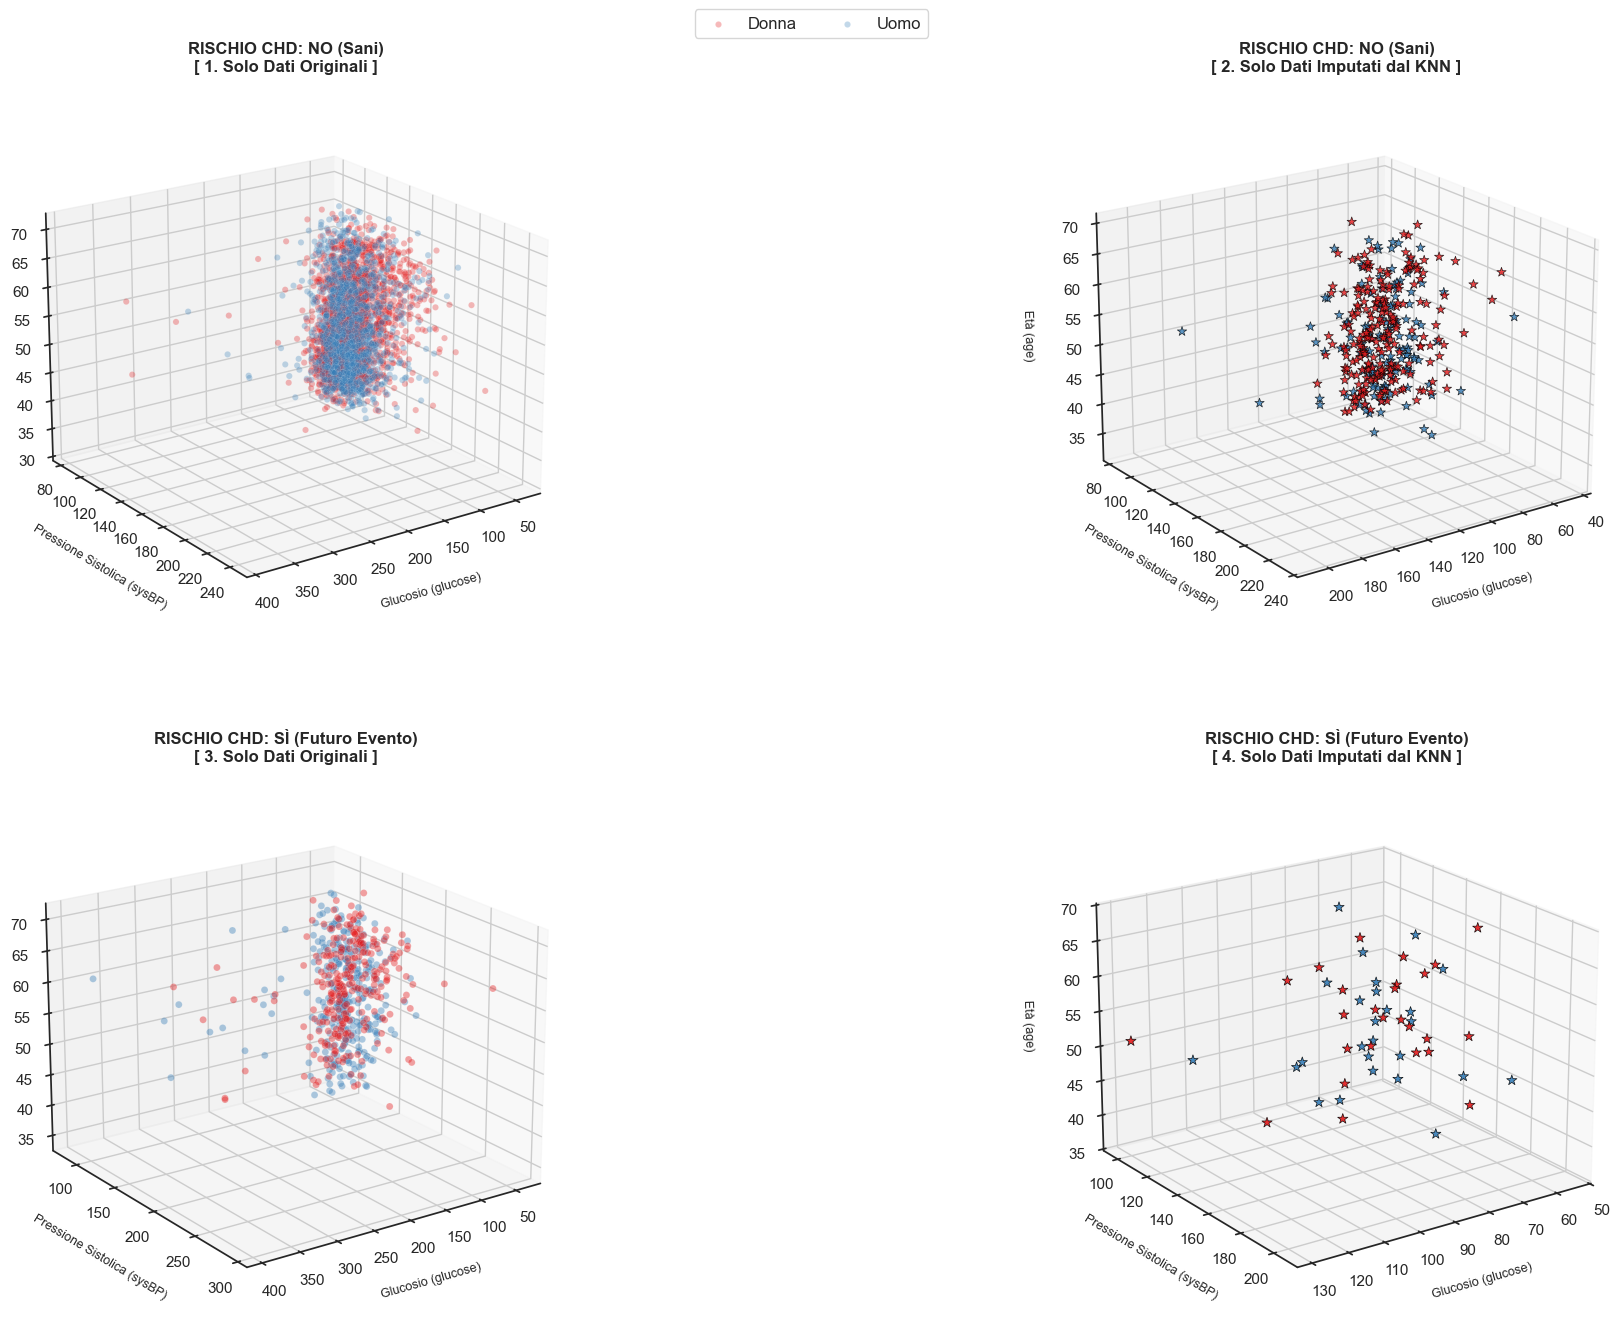

In [10]:
# Creazione di una griglia 3D che confronta la distribuzione spaziale dei dati originali vs quelli imputati con il KNN
colonne_plot = ['glucose', 'sysBP', 'age']
maschera_nan = dati_originali[colonne_plot].isna().any(axis=1)

# Divisione del dataset pulito in record originali e record con imputazione
pazienti_originali = dati_puliti[~maschera_nan]
pazienti_imputati = dati_puliti[maschera_nan]

# Palette per il sesso
palette_sesso = sns.color_palette("Set1", 2)
mappa_sesso = {
    0: (palette_sesso[0], "Donna"),
    1: (palette_sesso[1], "Uomo")
}

figura_3d = plt.figure(figsize=(20, 14))

# Configurazione dei 4 quadranti della griglia
quadranti_config = [
    {"riga": 0, "colonna": 0, "data": pazienti_originali, "target": 0, "titolo": "RISCHIO CHD: NO (Sani)\n[ 1. Solo Dati Originali ]", "alpha": 0.3, "marker": "o", "size": 20},
    {"riga": 0, "colonna": 1, "data": pazienti_imputati, "target": 0, "titolo": "RISCHIO CHD: NO (Sani)\n[ 2. Solo Dati Imputati dal KNN ]", "alpha": 0.8, "marker": "*", "size": 50},
    {"riga": 1, "colonna": 0, "data": pazienti_originali, "target": 1, "titolo": "RISCHIO CHD: SÌ (Futuro Evento)\n[ 3. Solo Dati Originali ]", "alpha": 0.4, "marker": "o", "size": 25},
    {"riga": 1, "colonna": 1, "data": pazienti_imputati, "target": 1, "titolo": "RISCHIO CHD: SÌ (Futuro Evento)\n[ 4. Solo Dati Imputati dal KNN ]", "alpha": 0.9, "marker": "*", "size": 60}
]

for conf in quadranti_config:
    dati_filtrati = conf["data"][conf["data"]['TenYearCHD'] == conf["target"]]
    pos = conf["riga"] * 2 + conf["colonna"] + 1
    ax = figura_3d.add_subplot(2, 2, pos, projection='3d')
    
    for sesso_val, (colore, etichetta) in mappa_sesso.items():
        sotto_gruppo = dati_filtrati[dati_filtrati['male'] == sesso_val]
        bordo_colore = 'black' if conf["marker"] == '*' else 'w'
        spessore_linea = 0.5 if conf["marker"] == '*' else 0.2
        
        ax.scatter(
            sotto_gruppo['glucose'], 
            sotto_gruppo['sysBP'],   
            sotto_gruppo['age'],     
            color=colore,
            marker=conf["marker"],
            s=conf["size"],
            alpha=conf["alpha"],
            edgecolors=bordo_colore,
            linewidths=spessore_linea,
            label=etichetta if (conf["riga"] == 0 and conf["colonna"] == 0) else ""
        )
    
    ax.set_xlabel('Glucosio (glucose)', labelpad=10, fontsize=9)
    ax.set_ylabel('Pressione Sistolica (sysBP)', labelpad=10, fontsize=9)
    ax.set_zlabel('Età (age)', labelpad=10, fontsize=9)
    ax.set_title(conf["titolo"], fontsize=12, fontweight='bold', pad=10)
    ax.view_init(elev=20, azim=55)

figura_3d.legend(loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=2, fontsize=12)
plt.tight_layout()
plt.subplots_adjust(top=0.90, hspace=0.25, wspace=0.15)
plt.show()